# Scrape Information from the FDA

The US FDA contains information to extract approvals for New Drug Application (NDA) or Therapeutic Biologics Applications (BLA). Information is pulled from their compiled data and from their CDER files. The following notebook will demo how to pull the information and generate a bar plot of the approvals over the years. The resulting bar graphs will be similar to what has been seen in in articles published yearly by Nature Reviews Drug Discovery ([Figure 1 here](https://www.nature.com/articles/d41573-026-00001-z)). The information is taken from:

- [Compilation of CDER New Molecular Entity (NME) Drug and New Biologic Approvals](https://www.fda.gov/drugs/drug-approvals-and-databases/compilation-cder-new-molecular-entity-nme-drug-and-new-biologic-approvals)
- [Novel Drug Approvals for X](https://www.fda.gov/drugs/novel-drug-approvals-fda/novel-drug-approvals-2026) where X is a given year.

In [1]:
from drug_nme import FDADataFetcher, FDAPlot

## Pull FDA Approvals
The FDA site contains a plethora of information for researchers. However, information can be scattered and difficult to parse. The class FDADataFetcher() looks to make it easier to pull FDA approved drugs for analysis.

Information is pulled from the [Compilation of CDER NME and New Biologic Approvals](https://www.fda.gov/drugs/drug-approvals-and-databases/compilation-cder-new-molecular-entity-nme-drug-and-new-biologic-approvals) site. At the time of writing this program, the compilation contains information from 1985 to 2024. To extract information from missing years, information was taken from another page containing [Novel Drug Approvals at FDA](https://www.fda.gov/drugs/development-approval-process-drugs/novel-drug-approvals-fda).

The information is then combined into a single table.

**NOTE**: At the time of writing the program, the Novel Drug Approvals does not contain the NME/BLA information. Instead, this is inferred using common naming convention (i.e. inib for small molecules and mab for biologics).

In [2]:
extract = FDADataFetcher()
df = extract.get_data()  # to get all data

# to get specific years
# df = df[df['Approval Year'].isin([2024, 2025, 2026])]
df.head()

,Drug Name,Active Ingredient,Approval Date,Approval Year,NME/BLA,Route of Administration(1),Orphan Drug Designation
0,Lifyorli,relacorilant,03/25/2026,2026,NME,NaN,NaN
1,Avlayah,tividenofusp alfa-eknm,03/24/2026,2026,NME,NaN,NaN
2,Icotyde,icotrokinra,03/17/2026,2026,NME,NaN,NaN
3,Lynavoy,linerixibat,03/17/2026,2026,NME,NaN,NaN
4,Yuviwel,navepegritide,02/27/2026,2026,NME,NaN,NaN


## Plotting
An additional class, FDAPlot(), is available to plot the information into a stacked bar chart. By initializing the class, which requires the table pulled from the class FDADataFetcher(), the table will be automatically formated for plotting. To visualize what the table looks like, use the show() method.

In [3]:
plot = FDAPlot(df)
plot.show(5)

,BLA,NME
Approval Year,,
1985,0,31
1986,3,20
1987,1,21
1988,0,20
1989,4,23


## Stacked Plot

Plotting the information is done using the stacked() method. This will generate a stacked bar plot for the FDA Approved Drugs. By default, they are separated by BLA or NME categories.

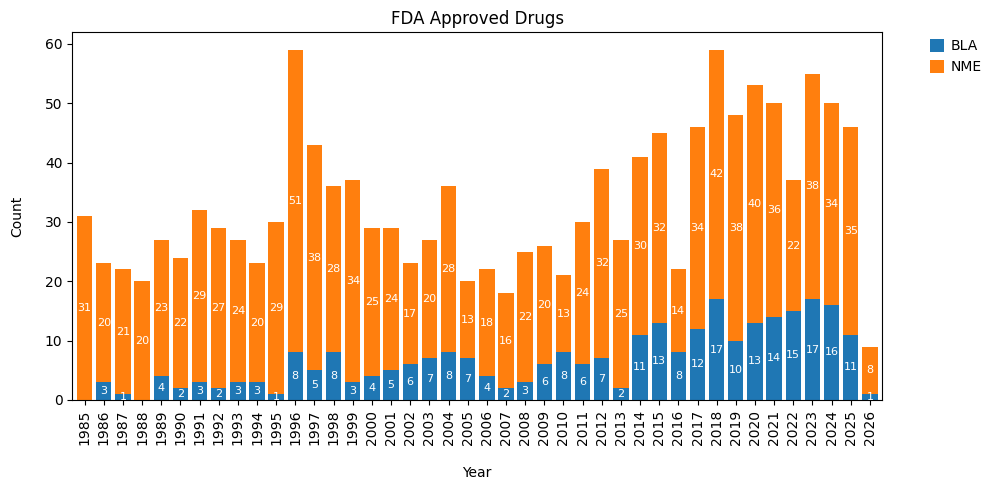

<Axes: title={'center': 'FDA Approved Drugs'}, xlabel='Year', ylabel='Count'>

In [4]:
plot.stacked(legend_loc='out right upper')

Specific years can be sliced from the table for plotting. The start and end years are giving as a tuple.

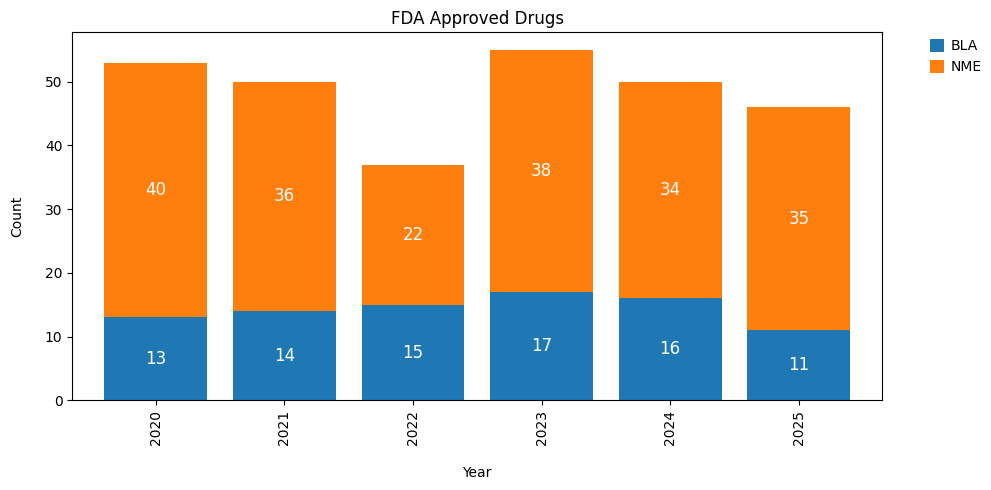

<Axes: title={'center': 'FDA Approved Drugs'}, xlabel='Year', ylabel='Count'>

In [5]:
plot.stacked(years=(2020,2025), fontsize=12, legend_loc='out right upper')

## Plotting for Drug Types
Additionally, specific drug types can be labeled (small molecule, antibody, protein, etc). This can provide plots with more details. The information is pulled by matching the Active ingredient with the labels found on ChEMBL. The information is prepared by using the **add_types()** method.

In [6]:
df = extract.add_types(df)
df.head()

Fetching Drug Types From ChEMBL: 100%|██████████| 1396/1396 [00:04<00:00, 309.61it/s]


,Drug Name,Active Ingredient,Approval Date,Approval Year,NME/BLA,Route of Administration(1),Orphan Drug Designation,Type
0,Lifyorli,relacorilant,03/25/2026,2026,NME,NaN,NaN,Small molecule
1,Avlayah,tividenofusp alfa-eknm,03/24/2026,2026,NME,NaN,NaN,Protein
2,Icotyde,icotrokinra,03/17/2026,2026,NME,NaN,NaN,Small molecule
3,Lynavoy,linerixibat,03/17/2026,2026,NME,NaN,NaN,Small molecule
4,Yuviwel,navepegritide,02/27/2026,2026,NME,NaN,NaN,Protein


This is an example of the drug types available.

In [7]:
df.Type.unique()

<StringArray>
[         'Small molecule',                 'Protein',
                  'Enzyme',                'Antibody',
         'Oligonucleotide', 'Antibody drug conjugate',
         'Oligosaccharide']
Length: 7, dtype: str

## Plotting By Drug Types
With the additional "Type" column, the input data can then processed using the **FDAPlot()** class to process the table as seen above, with the additional counts for drug types for a given year.

In [8]:
plot = FDAPlot(df)
plot.show(5)

,BLA,NME,Antibody,Antibody drug conjugate,Enzyme,Oligonucleotide,Oligosaccharide,Protein,Small molecule
Approval Year,,,,,,,,,
1985,0,31,0,0,0,0,0,2,29
1986,3,20,1,0,0,0,0,3,19
1987,1,21,0,0,1,0,0,1,20
1988,0,20,0,0,0,0,0,1,19
1989,4,23,0,0,1,0,0,4,22


The information can be extracted and then plotted in a stacked plot, similar to the BLA/NME figure above.

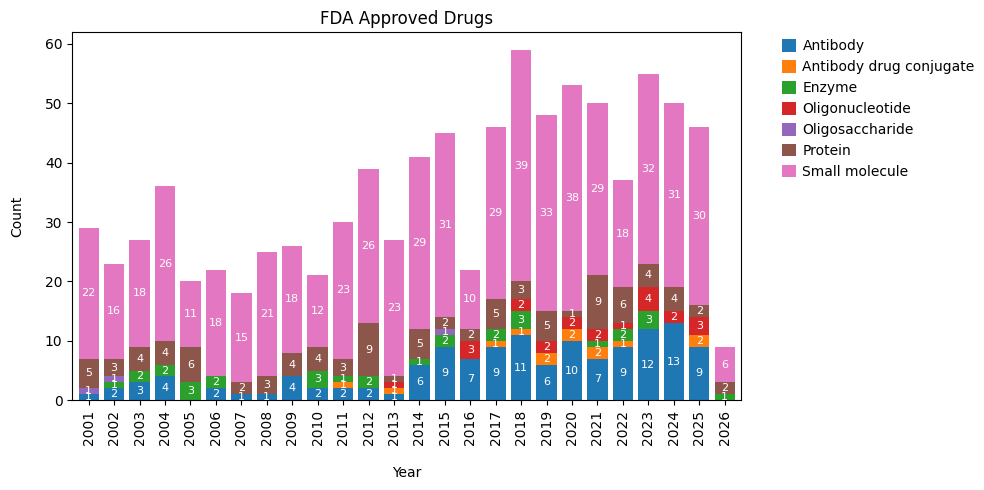

<Axes: title={'center': 'FDA Approved Drugs'}, xlabel='Year', ylabel='Count'>

In [9]:
cols = sorted(df.Type.unique())
plot.stacked(cols=cols, years=(2001, 2026), legend_loc='out right upper')

## Donut Plot

A donut plot can also be generated using the aforementioned data. Here a specific year can be extracted for each drug Type. This information is given upon **FDAPlot()** initialization.

In [10]:
donut_data = FDAPlot(df, sort_col=['Type', 'Approval Year'])
donut_data.show(5)

,Type,Approval Year,Count
0,Antibody,1986,1
1,Antibody,1992,1
2,Antibody,1994,1
3,Antibody,1996,4
4,Antibody,1997,2


The information can be sorted for specific years. In this case, the information will be filtered to contain drug types approved during 2024.

In [11]:
# extract instance variable
year_data = donut_data.df

# filter for year 2009
year = year_data[year_data['Approval Year'] == 2024].reset_index(drop=True)
year

,Type,Approval Year,Count
0,Antibody,2024,13
1,Oligonucleotide,2024,2
2,Protein,2024,4
3,Small molecule,2024,31


Plotting is done using the **donut()** method.

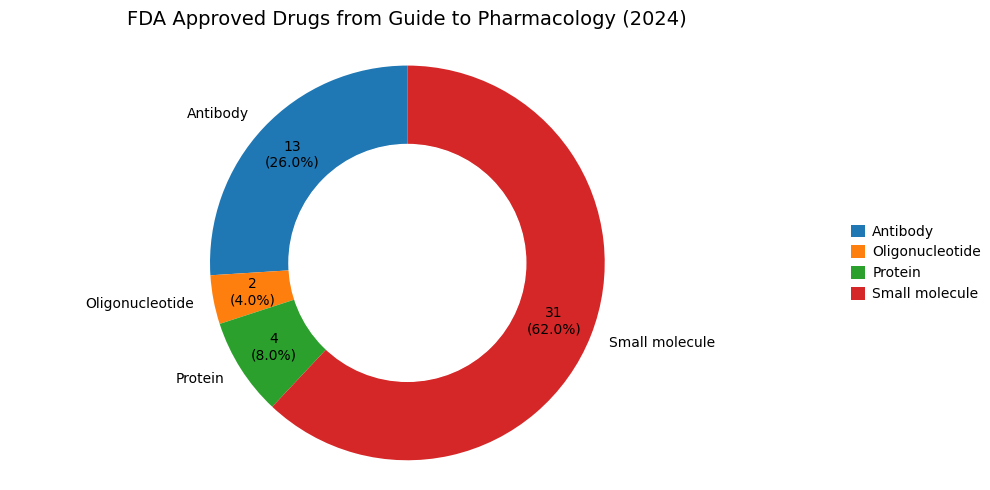

In [12]:
title = 'FDA Approved Drugs from Guide to Pharmacology (2024)'
palette = ['#ddf2d8', '#c2e7c0', '#61bdcd', '#3597c4', '#0d6dae']
donut_data.donut(year, title=title, legend_loc='out right center')

## Bonus Donut

As a bonus, we can plot drug approvals for a specific time range. This sample will show a "cleaned" up version of preparing the data. In this example we will look at the drug types approved from 2021 - 2024.

In [13]:
range = df[df['Approval Year'] >= 2021].reset_index(drop=True)
donut_data = FDAPlot(range, sort_col=['Type'])
donut_data.show(5)

,Type,Count
0,Antibody,50
1,Antibody drug conjugate,5
2,Enzyme,7
3,Oligonucleotide,12
4,Protein,27


There are additional params in the **donut()** method for modifying the figure. The plot is modified here to avoid text clashes. The final figure can be saved as a .png or .svg format using the **savepath** param.

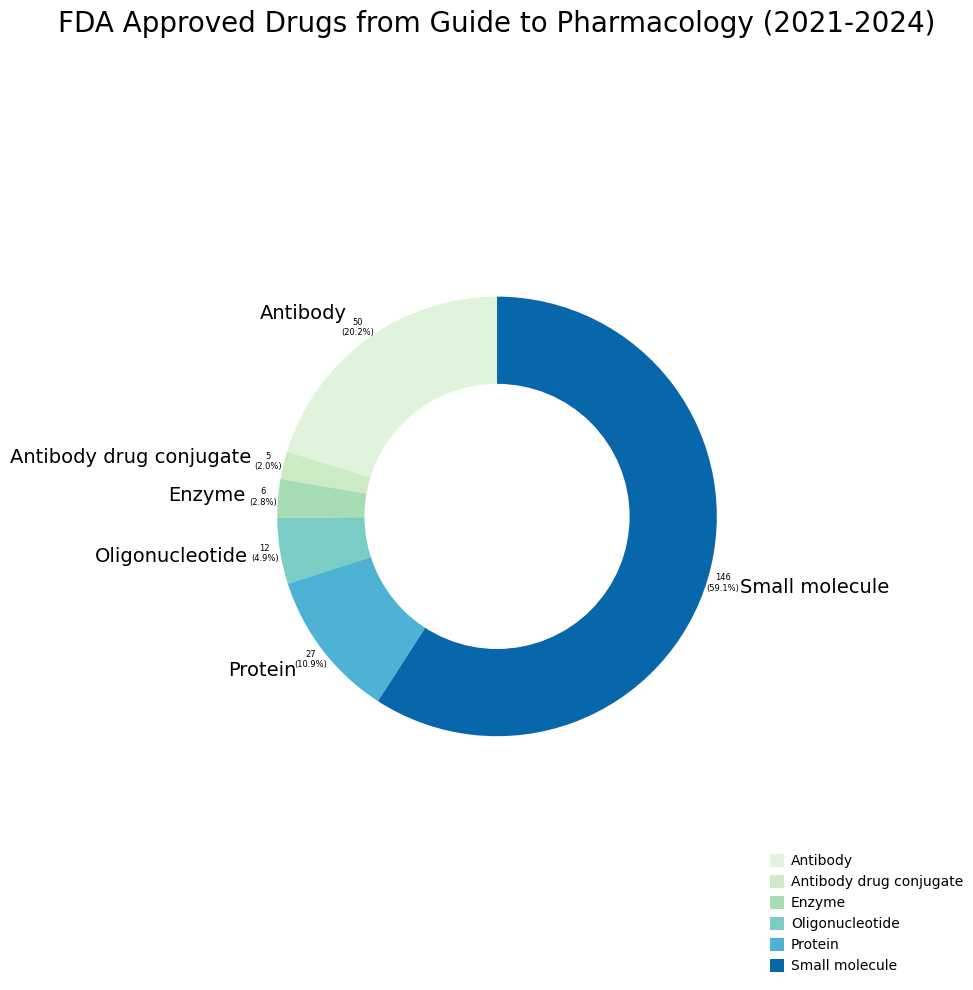

In [14]:
title = 'FDA Approved Drugs from Guide to Pharmacology (2021-2024)'
palette = ['#e0f3db', '#ccebc5', '#a7ddb5', '#7accc4', '#4db2d3', '#0867ab', '#1d6185']

donut_data.donut(title=title, palette=palette, legend_loc='out right lower', figsize=(10, 10), titlesize=20, fontsize=14, annotsize=6, pctdistance=1.07, labeldistance=1.15)